# 인공지능(머신러닝)
## 지도학습: 문제, 정답을 알려주고 패턴 찾는 것
* 분류분석, 회귀분석
## 비지도학습: 문제만 알려주고 알고리즘이 알아서 패턴을 찾는 것
* 군집분석 

# 분류 분석의 대표적인 알고리즘 Tree 기반 모델
# 의사결정나무(Decision Tree)
* Decision Tree는 데이터를 분할해서 조건문처럼 분기해 나가면서 예측하는 Tree 기반 모델
* 스무고개와 비슷하게 계속 질문을 던져서 분리
### 장점
* 직관적이고 해석 쉬움
* feature scaling(변수)이 필요 없음(MinMax, StandardScaler 사용을 하지 않아도 됨)
* 범주형(DecisionTreeClassifier), 수치형(DecisionTreeRegressor) 자료 모두를 분석 할 수 있음
* 시각화가 쉽고 직관적
### 단점
* 과적합(overfitting)이 잘 일어남 (**과적합**: 모델이 학습 데이터에만 너무 잘 맞고, 새로운 데이터에는 오히려 성능이 떨어지는 상태)
* 최적 트리를 찾기 어렵고 시간이 오래 걸릴 수 있음

0. 필요한 라이브러리 로딩
1. 타이타닉 데이터 로딩
2. 데이터 전처리(결측값처리, 이상값 탐지)
3. EDA(탐색적 데이터 분석, 각 컬럼의 데이터 분포, 그래프로/ 문자 -> 숫자, 상관관계)
4. Fearture Engineering(변수 선택, 새로운 특성 생성
5. 최종 선택된 변수를 독립변수(X)와 종속변수(y)로 분리
6. sklearn의 train_test_split을 불러와서 train, test 세트로 분리
7. 카테고리 변수의 더미 변수화(one-hot encoding)
8. sklearn에서 DecisionTreeClassifier를 불러와서 모델 훈련
9. test 세트를 모델에 넣어서 예측값 생성(pred)
10. accuracy_score(), classificatio_report()를 이용해서 모델의 성능 확인

# 0. 필요한 라이브러리 로딩

In [3]:
! pip install koreanize_matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 1. 타이타닉 데이터 로딩

In [5]:
data = pd.read_csv("./data/Titanic_train.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 2. 데이터 전처리(결측값처리, 이상값 탐지)

In [6]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
data.info() # Age, Cabin, Embarked 컬럼에 결측치 존재 확인

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# 결측 비율 확인
data.isna().sum()/len(data)*100 

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
# 1. Age부터 처리해보자 => 평균으로 대치
data['Age']=data['Age'].fillna(data['Age'].mean())

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
# 2. Cabin 처리해보자 => 결측율이 77%이므로 컬럼 자체를 삭제
data=data.drop('Cabin', axis=1) # axis=1 --> 열을 건드린다

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [13]:
# 3. Embarked 처리해보자 => 최빈값으로 대체
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
data['Embarked']=data['Embarked'].fillna(data['Embarked'].mode()[0])

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [16]:
# PassengerId는 굳이 필요없으니까 컬럼을 삭제한다
data=data.drop('PassengerId', axis=1)

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


# 3. EDA(탐색적 데이터 분석, 각 컬럼의 데이터 분포 ->그래프/ 문자 -> 숫자/ 상관관계 살펴보기)

In [19]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='str')

In [20]:
cate_cols = data[['Survived', 'Pclass', 'Name', 'Sex','SibSp', 'Parch', 'Ticket','Embarked']]
num_cols = data[['Age', 'Fare']]

============================== Survived ==============================
Survived
0    549
1    342
Name: count, dtype: int64


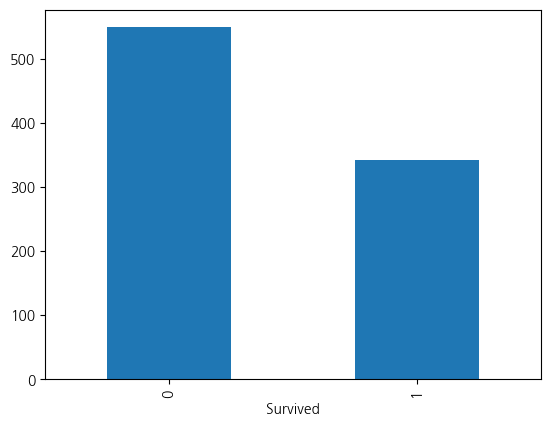

============================== Pclass ==============================
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


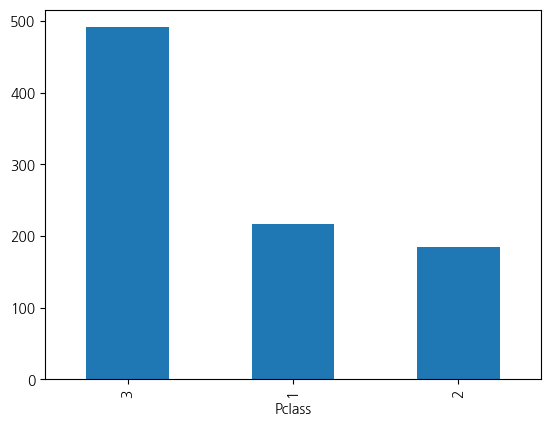

============================== Name ==============================
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64


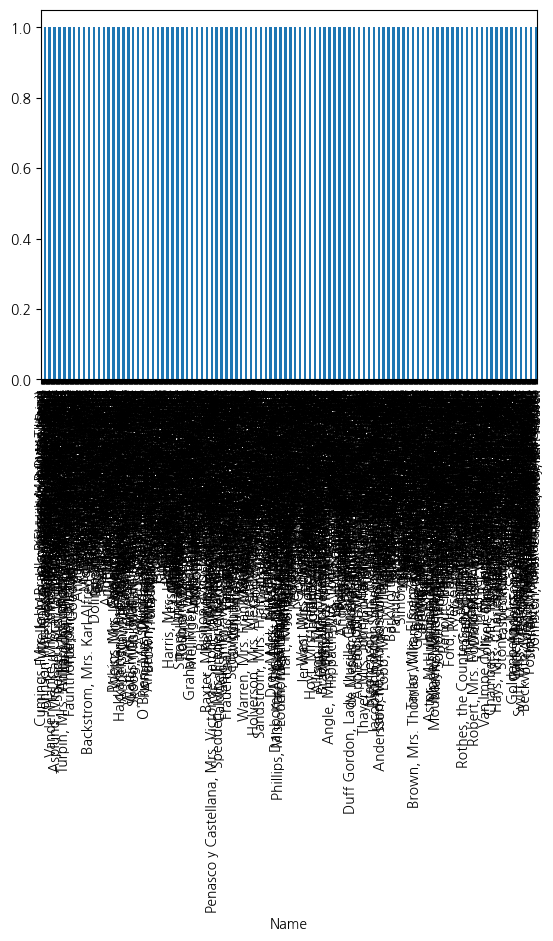

============================== Sex ==============================
Sex
male      577
female    314
Name: count, dtype: int64


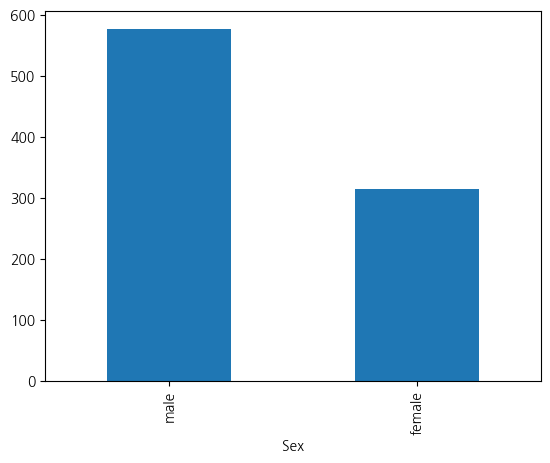

============================== SibSp ==============================
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
============================== SibSp ==============================
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


In [21]:
for col in cate_cols.columns:
    print("="*30, col, "="*30)
    print(cate_cols[col].value_counts())
    cate_cols[col].value_counts().plot(kind='bar')
    plt.show()

In [22]:
for col in num_cols.columns:
    print("=" * 30, col, "="*30)
    display(num_cols[col].describe())
    num_cols[col].plot(kind='box')
    plt.show()
    num_cols[col].plot(kind='hist')
    plt.show()

# 4. Feature Engineering (변수 선택, 새로운 특성 생성)

In [23]:
for col in data.columns[1:]:
    print("=" * 30, col, "="*30)
    display(data[['Survived', col]].groupby(col).mean())

## sibsp + parch = family
## ticket, name 삭제

In [24]:
data['family']=data['SibSp']+data['Parch']
data.head()

In [25]:
data = data.drop(['Ticket', 'Name', 'SibSp', 'Parch'], axis=1)
data.head

## 문자로 되어있는 컬럼 숫자로 변환하기 (상관관계를 보기 위함)

In [26]:
data.head(2)

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le = LabelEncoder()
data['Sex']=le.fit_transform(data['Sex'])
data.head()

In [29]:
data.nunique() # LabelEncoder로 바꿀 경우 서열이 생길 수 있으므로  one-hot encoding으로 바꿔줌

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
ohe_df = ohe.fit_transform(data[['Embarked']])
ohe_df = pd.DataFrame(ohe_df, index=data.index, columns=ohe.get_feature_names_out())
ohe_df

In [32]:
pd.concat([data, ohe_df], axis=1)

In [33]:
data=pd.concat([data, ohe_df], axis=1)

In [34]:
data.head()

In [35]:
data=data.drop('Embarked', axis=1)
data.head()

## 각 변수간 상관관계 보기

In [36]:
data.corr(method = "spearman")

In [37]:
sns.heatmap(data.corr(method='spearman'), annot=True, linewidths=1)

In [38]:
data=data.drop('Fare', axis=1)   # Fare 삭제 왜????????
data.head()

## 나이 컬럼 구간화

In [39]:
data['Age']=pd.cut(data['Age'], 
       bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
       right = False,
       labels = ['under10s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s'])
data.head(2)

In [40]:
data=pd.get_dummies(data, columns=['Age'])
data.head(2)

# 5. 최종 선택된 변수를 독립변수(X)와 종속변수(y)로 분리

In [41]:
X = data.drop('Survived', axis=1)
y = data['Survived']

# 6. sklearn의 train_test_split을 불러와서 train, test 세트로 분리

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 의사결정나무 불러와서 분석하기

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [45]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [46]:
for i in range(1,11):
    dtc = DecisionTreeClassifier(max_depth=3)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print("="*30, i, "="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

In [47]:
from sklearn.tree import plot_tree

In [48]:
plt.figure(figsize=(20, 10))
plot_tree(dtc, 
         feature_names=X_train.columns,
        class_names = ['not survived', 'survived'],
         filled=True,
         rounded=True,
         fontsize=12)
plt.title("의사결정나무 그래프")
plt.show()

# 7. 카테고리 변수의 더미 변수화(one-hot encoding)

# 8. sklearn에서 DecisionTreeClassifier를 불러와서 모델 훈련

# 9. test 세트를 모델에 넣어서 예측값 생성(pred)

# 10. accuracy_score(), classificatio_report()를 이용해서 모델의 성능 확인 

# 💧 데이터 누수(Data Leakage)

## 📌 데이터 누수란?

> 모델이 학습 과정에서 "미래 정보" 또는 "정답과 관련된 정보"를 미리 사용해버리는 것

즉,

👉 모델이 알면 안 되는 정보를 미리 보고 학습하는 상황

---

## 🎓 시험 비유로 이해하기

- 우리는 시험을 잘 보기 위해 공부한다.
- 교과서로 공부하면 정상.
- 시험지를 미리 보고 공부하면?

👉 시험 점수는 잘 나오지만  
👉 실제 실력은 없음.

이게 바로 **데이터 누수**입니다.

---

# 🤖 머신러닝에서의 데이터 누수 예시

## ❌ 잘못된 예 1: One-Hot Encoding을 전체 데이터에 적용

```python
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

# ❌ 전체 데이터에 대해 fit (누수 발생)
ohe.fit(df[['Embarked']])
```
## 🚨 문제점

- test 데이터에만 존재하는 범주까지
- 모델이 이미 알고 있음

👉 미래 정보 사용
👉 누수 발생

## 올바른 방법
```python
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

ohe = OneHotEncoder(handle_unknown='ignore')

# ✅ train에만 fit
ohe.fit(X_train[['Embarked']])

# test는 transform만
X_test_ohe = ohe.transform(X_test[['Embarked']])
```



## ❌ 잘못된 예 2: StandardScaler를 전체 데이터에 적용
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# ❌ 전체 데이터 평균/표준편차 계산 (누수 발생)
scaler.fit(df[['Age']])
```

## 🚨 문제점

- StandardScaler는 내부적으로:
평균(mean)
표준편차(std)
를 계산합니다.

- test 데이터가 평균 계산에 포함되면?

👉 미래 통계를 이미 사용
👉 누수 발생

## 올바른 방법
```python
scaler = StandardScaler()

# ✅ train에만 fit
scaler.fit(X_train[['Age']])

# test는 transform만
X_test_scaled = scaler.transform(X_test[['Age']])
```

# 데이터 누수 없이 처리해서 재분석하기

# 문자로 되어 있는 컬럼 숫자로 변환하기

# 🟦 문자 컬럼 숫자로 변환하기 정리

## ✅ 1) 머신러닝 모델은 숫자만 입력받을 수 있다
범주형(카테고리) 변수는 문자 형태 그대로는 모델이 처리할 수 없다.

예시:
- `Sex = ["male", "female"]`
- `Embarked = ["C", "Q", "S"]`

문자 데이터는 **순서/거리 개념이 없기 때문에**  
머신러닝 모델에 입력하기 위해서는 반드시 **숫자로 변환**해야 한다.

---

## ✅ 2) LabelEncoder는 범주 간 “순서를 만들어 버리는 문제”가 있다
LabelEncoder는 각 범주를 숫자로 변환하되 **임의의 순서를 부여한다.**

| Category | Encoded |
|----------|---------|
| C        | 0       |
| Q        | 1       |
| S        | 2       |

그러나 실제로는:
- C < Q < S  
- 또는 Q > S 같은 **순서/크기 관계가 존재하지 않는다.**

이러한 잘못된 순서 정보는  
Logistic Regression, SVM, Linear Model 같은  
**거리 기반 모델에 심각한 오류(데이터 왜곡)**를 만든다.

---

## ✅ 3) OneHotEncoder는 “순서를 없애고” 모든 범주를 독립 컬럼으로 분리한다
One-Hot Encoding은 각 범주를 **독립된 컬럼**으로 만들고  
해당 범주일 때만 1, 아니면 0을 넣는 방식이다.

예: `Embarked = ["C", "Q", "S"]`

| Embarked_C | Embarked_Q | Embarked_S |
|------------|------------|------------|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

✅ 범주 간 **순서·거리 개념이 제거됨**  
✅ 대부분의 모델에서 **성능 향상**  
✅ 데이터 해석이 더 직관적  
✅ train/test split 후에도 안정적으로 작동 (OneHotEncoder 사용 시)

---

# 📊 범주형 인코딩 방법 비교표

| 항목 | Label Encoding | One-Hot Encoding (sklearn) | get_dummies (pandas) |
|------|----------------|----------------------------|----------------------|
| 출력 형태 | 숫자 1개 컬럼 | 범주 수만큼 컬럼 생성 | 범주 수만큼 컬럼 생성 |
| 예시 | 남자=0, 여자=1 | Sex_male, Sex_female | Sex_male, Sex_female |
| 순서 왜곡 위험 | 있음 ⚠️ | 없음 | 없음 |
| 차원 증가 | 없음 | 있음 | 있음 |
| handle_unknown 지원 | 없음 | 있음 (`handle_unknown='ignore'`) | 없음 |
| train/test 분리 안전성 | 중간 | ⭐⭐⭐ 안전 | 위험 가능 ⚠️ |
| Pipeline 사용 가능 | 가능 | 가능 | 불가능 |
| 데이터 누수 위험 | 중간 | 낮음 | 높음 (전체 데이터에 적용 시) |
| 실무 추천도 | 타겟(y)용 ⭐ | ⭐⭐⭐⭐ 추천 | 간단 EDA용 |

---

# 🎯 사용 가이드

- **타겟(y) 인코딩** → `LabelEncoder`
- **범주형 feature 전처리 (실무)** → `OneHotEncoder`
- **빠른 탐색/EDA용** → `pd.get_dummies`

---

# ⚠️ 핵심 주의사항

- `fit()`은 반드시 **train 데이터에만**
- test 데이터는 `transform()`만 수행
- `get_dummies()`는 train/test 분리 전에 전체 데이터에 적용하면 **데이터 누수 발생 가능**

In [49]:
data

In [50]:
from sklearn.preprocessing import OneHotEncoder

In [51]:
X = data.drop('Survived', axis=1)
y= data['Survived']

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [54]:
# 범주형, 수치형 컬럼 구분
cat_cols = ['Sex', 'Embarked']
num_cols = [col for col in X_train.columns if col not in cat_cols]

In [55]:
cat_cols

In [56]:
num_cols

In [57]:
# OneHotEncoder 설정
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [58]:
# train 데이터로 훈련 fit
ohe.fit(X_train[cat_cols])

In [ ]:
# train, test에 각각 transform
X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [ ]:
# onehot 인코딩된 컬럼 이름 출력 
ohe_cols = ohe.get_feature_names_out(cat_cols)
ohe_cols

In [ ]:
# dataframe으로 변환
ohe_train_df=pd.DataFrame(X_train_ohe, index=X_train.index, columns=ohe_cols)
ohe_test_df=pd.DataFrame(X_test_ohe, index=X_test.index, columns=ohe_cols)
display(ohe_train_df)
display(ohe_test_df)

In [ ]:
X_train_final = pd.concat([X_train, ohe_train_df], axis=1)
X_train_final

In [ ]:
X_test_final = pd.concat([X_test, ohe_test_df], axis=1)
X_test_final

In [ ]:
X_train_final=X_train_final.drop(['Sex', 'Embarked'], axis=1)
X_test_final=X_test_final.drop(['Sex', 'Embarked'], axis=1)

In [ ]:
X_train_final

In [ ]:
X_test_final

# one-hot Encoding 간단하게 하는 방법
* ColumnTransformer

In [ ]:
X_train

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), 
        ['Sex', 'Embarked'])
    ], 
    remainder='passthrough'
)
ct.set_output(transform='pandas')

X_train_final2 = ct.fit_transform(X_train)
X_test_final2 = ct.transform(X_test)

In [ ]:
X_train_final2

# 모델 선택 및 분석

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_final2, y_train)
pred = dtc.predict(X_test_final2)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# 🌳 DecisionTreeClassifier 하이퍼파라미터 정리

---

## 1️⃣ 분할 기준 / 분할 방식

| 파라미터 | 의미 | 주요 옵션 | 값 변화 효과 | 실무 중요도 |
|-----------|------|------------|---------------|--------------|
| `criterion` | 분할 품질 평가 기준 | `"gini"`, `"entropy"` | 분할 판단 기준이 달라짐 | ⭐⭐⭐ |
| `splitter` | 분할 탐색 방식 | `"best"`, `"random"` | random 사용 시 약간의 규제 효과 | ⭐ |

---

## 2️⃣ 트리 크기 제한 (과적합 제어 핵심)

| 파라미터 | 의미 | 기본값 | 값 ↑ 효과 | 실무 중요도 |
|-----------|------|--------|------------|--------------|
| `max_depth` | 트리 최대 깊이 | None | 깊이 제한 → 과적합 감소 | ⭐⭐⭐⭐ |
| `min_samples_split` | 분할 최소 샘플 수 | 2 | 분할 덜 발생 → 단순 모델 | ⭐⭐⭐ |
| `min_samples_leaf` | 리프 최소 샘플 수 | 1 | 작은 리프 방지 → 안정성 증가 | ⭐⭐⭐⭐ |
| `max_leaf_nodes` | 리프 개수 제한 | None | 모델 단순화 | ⭐⭐ |
| `min_impurity_decrease` | 최소 불순도 감소량 | 0 | 의미 없는 분할 방지 | ⭐⭐ |

---

## 3️⃣ Feature 선택 관련

| 파라미터 | 의미 | 옵션 | 효과 | 실무 중요도 |
|-----------|------|--------|------|--------------|
| `max_features` | 분할 시 고려할 feature 수 | None, `"sqrt"`, `"log2"`, int, float | feature 제한 → 규제 효과 | ⭐⭐⭐ |

---

## 4️⃣ 불균형 데이터 대응

| 파라미터 | 의미 | 옵션 | 효과 | 실무 중요도 |
|-----------|------|--------|------|--------------|
| `class_weight` | 클래스 가중치 | None, `"balanced"` | 소수 클래스 recall 증가 | ⭐⭐⭐ |

---

## 5️⃣ 가지치기 (Pruning)

| 파라미터 | 의미 | 기본값 | 값 ↑ 효과 | 실무 중요도 |
|-----------|------|--------|------------|--------------|
| `ccp_alpha` | 비용복잡도 가지치기 | 0 | 트리 단순화, 과적합 감소 | ⭐⭐⭐⭐ |

---

## 6️⃣ 재현성

| 파라미터 | 의미 | 효과 | 실무 중요도 |
|-----------|------|------|--------------|
| `random_state` | 랜덤 고정 | 항상 동일 결과 보장 | ⭐⭐⭐⭐⭐ |

---

# 🔥 실무 튜닝 우선순위

1. `max_depth`
2. `min_samples_leaf`
3. `min_samples_split`
4. `ccp_alpha`
5. `max_features`
6. `class_weight` (불균형일 때)

---

# 🎯 핵심 요약

- 과적합 제어 핵심 → `max_depth`, `min_samples_leaf`, `ccp_alpha`
- 불균형 대응 → `class_weight`
- 재현성 확보 → `random_state`

In [ ]:
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(X_train_final2, y_train)
pred = dtc.predict(X_test_final2)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [ ]:
dtc2 = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dtc2.fit(X_train_final2, y_train)
pred2 = dtc2.predict(X_test_final2)
print(accuracy_score(y_test, pred2))
print(classification_report(y_test, pred2)) # precision과 recall은 반비례 관계

In [ ]:
for i in range(1,30): # max_depth=3이 최적이구나 알 수 있음
    dtc3 = DecisionTreeClassifier(max_depth=i, class_weight='balanced', random_state=42)
    dtc3.fit(X_train_final2, y_train)
    pred3 = dtc3.predict(X_test_final2)
    print("="*30, i, "="*30)
    print(accuracy_score(y_test, pred3))
    print(classification_report(y_test, pred3))

In [ ]:
from sklearn.tree import plot_tree

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    dtc2,
feature_names=X_test_final2.columns,
filled=True,
rounded=True,
fontsize=10)
plt.title('의사결정나무 모델2 max_depth3')
plt.show()